# BirdCLEF+ 2026 - exp001 Training

**Google Colab (GPU) で実行する学習ノートブック**

完了後、`output/weights/best_fold0.pth` を Kaggle Dataset `birdclef2026-exp001-weights` としてアップロードしてください。

In [ ]:
!pip install -q timm librosa scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── パス設定 ──────────────────────────────────────────────────
BASE_DIR        = '/content/drive/Othercomputers/maeke/work/kaggle/birdclef-2026'
TRAIN_CSV       = f'{BASE_DIR}/train.csv'
TAXONOMY_CSV    = f'{BASE_DIR}/taxonomy.csv'
SAMPLE_SUB_CSV  = f'{BASE_DIR}/sample_submission.csv'
TRAIN_AUDIO_DIR = f'{BASE_DIR}/train_audio'
WEIGHT_DIR      = f'{BASE_DIR}/experiment/exp001/output/weights'
LOG_DIR         = f'{BASE_DIR}/experiment/exp001/output/logs'

import os
os.makedirs(WEIGHT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,    exist_ok=True)

import pathlib
for label, path in [('TRAIN_CSV', TRAIN_CSV), ('SAMPLE_SUB_CSV', SAMPLE_SUB_CSV), ('TRAIN_AUDIO_DIR', TRAIN_AUDIO_DIR)]:
    print(f'  {"OK" if pathlib.Path(path).exists() else "NG"} {label}: {path}')

  OK TRAIN_CSV: /content/drive/Othercomputers/maeke/work/kaggle/birdclef-2026/train.csv
  OK SAMPLE_SUB_CSV: /content/drive/Othercomputers/maeke/work/kaggle/birdclef-2026/sample_submission.csv
  OK TRAIN_AUDIO_DIR: /content/drive/Othercomputers/maeke/work/kaggle/birdclef-2026/train_audio


In [ ]:
# ── ハイパーパラメータ ────────────────────────────────────────
CFG = dict(
    # 音声
    sample_rate     = 32000,
    n_samples       = 32000 * 5,
    n_mels          = 128,
    n_fft           = 1024,
    hop_length      = 320,
    fmin            = 20,
    fmax            = 16000,
    # 学習
    seed            = 42,
    n_folds         = 5,
    train_fold      = 0,
    epochs          = 3,
    batch_size      = 32,
    num_workers     = 2,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    warmup_epochs   = 1,
    use_amp         = True,
    # モデル
    model_name      = 'tf_efficientnet_b0_ns',
    num_classes     = 234,
    in_channels     = 1,
    # Augmentation
    use_mixup       = True,
    mixup_alpha     = 0.5,
    mixup_prob      = 0.5,
    gaussian_noise  = True,
    noise_std       = 0.005,
    noise_prob      = 0.5,
    time_shift      = True,
    time_shift_prob = 0.5,
)

In [ ]:
import ast
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import timm
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch  : {torch.__version__}')
print(f'device : {DEVICE}')

torch  : 2.10.0+cu128
device : cuda


In [ ]:
# ── ユーティリティ ────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = self.avg = self.sum = self.count = 0.0
    def update(self, val, n=1):
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def compute_roc_auc(targets, preds, labels):
    aucs = []
    for i in range(len(labels)):
        if targets[:, i].sum() == 0:
            continue
        try:
            aucs.append(roc_auc_score(targets[:, i], preds[:, i]))
        except Exception:
            pass
    return float(np.mean(aucs)) if aucs else 0.0

set_seed(CFG['seed'])

In [ ]:
# ── Dataset ───────────────────────────────────────────────────
class BirdCLEFDataset(Dataset):
    def __init__(self, df, labels, mode='train'):
        self.df        = df.reset_index(drop=True)
        self.labels    = labels
        self.label2idx = {l: i for i, l in enumerate(labels)}
        self.mode      = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        audio = self._load_audio(row['filename'])
        audio = self._crop_or_pad(audio)
        if self.mode == 'train':
            audio = self._augment(audio)
        image = torch.tensor(self._to_melspec(audio)).unsqueeze(0)
        return image, self._get_label(row)

    def _load_audio(self, filename):
        audio, _ = librosa.load(f'{TRAIN_AUDIO_DIR}/{filename}', sr=CFG['sample_rate'], mono=True)
        return audio

    def _crop_or_pad(self, audio):
        n = CFG['n_samples']
        if len(audio) >= n:
            start = np.random.randint(0, len(audio) - n + 1) if self.mode == 'train' else (len(audio) - n) // 2
            audio = audio[start:start + n]
        else:
            audio = np.pad(audio, (0, n - len(audio)), mode='constant')
        return audio.astype(np.float32)

    def _to_melspec(self, audio):
        mel = librosa.feature.melspectrogram(
            y=audio, sr=CFG['sample_rate'], n_mels=CFG['n_mels'],
            n_fft=CFG['n_fft'], hop_length=CFG['hop_length'],
            fmin=CFG['fmin'], fmax=CFG['fmax'],
        )
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-8)
        return mel.astype(np.float32)

    def _get_label(self, row):
        label = np.zeros(len(self.labels), dtype=np.float32)
        if row['primary_label'] in self.label2idx:
            label[self.label2idx[row['primary_label']]] = 1.0
        secondary = row['secondary_labels']
        if isinstance(secondary, str):
            try:
                secondary = ast.literal_eval(secondary)
            except Exception:
                secondary = []
        for sl in secondary:
            if sl in self.label2idx:
                label[self.label2idx[sl]] = 1.0
        return torch.tensor(label, dtype=torch.float32)

    def _augment(self, audio):
        if CFG['gaussian_noise'] and np.random.random() < CFG['noise_prob']:
            audio = audio + np.random.randn(len(audio)).astype(np.float32) * CFG['noise_std']
        if CFG['time_shift'] and np.random.random() < CFG['time_shift_prob']:
            audio = np.roll(audio, np.random.randint(-CFG['sample_rate'] // 2, CFG['sample_rate'] // 2))
        return audio.astype(np.float32)

def mixup(images, labels, alpha=0.5):
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(images.size(0), device=images.device)
    return lam * images + (1 - lam) * images[perm], lam * labels + (1 - lam) * labels[perm]

In [ ]:
# ── モデル ────────────────────────────────────────────────────
class BirdCLEFModel(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            CFG['model_name'], pretrained=pretrained,
            in_chans=CFG['in_channels'], num_classes=0, global_pool='avg',
        )
        self.head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(self.backbone.num_features, CFG['num_classes']),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

In [ ]:
# ── データ読み込み・fold分割 ───────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
sub_df   = pd.read_csv(SAMPLE_SUB_CSV, nrows=0)
LABELS   = [c for c in sub_df.columns if c != 'row_id']

skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])
train_df['fold'] = -1
for fold, (_, val_idx) in enumerate(skf.split(train_df, train_df['primary_label'])):
    train_df.loc[val_idx, 'fold'] = fold

FOLD  = CFG['train_fold']
tr_df = train_df[train_df['fold'] != FOLD].reset_index(drop=True).sample(1000,random_state=42)
va_df = train_df[train_df['fold'] == FOLD].reset_index(drop=True).sample(1000,random_state=42)
print(f'Fold {FOLD}: train={len(tr_df)}, valid={len(va_df)}, classes={len(LABELS)}')

Fold 0: train=1000, valid=1000, classes=234


In [ ]:
# ── DataLoader ────────────────────────────────────────────────
tr_loader = DataLoader(
    BirdCLEFDataset(tr_df, LABELS, mode='train'),
    batch_size=CFG['batch_size'], shuffle=True,
    num_workers=CFG['num_workers'], pin_memory=True, drop_last=True,
)
va_loader = DataLoader(
    BirdCLEFDataset(va_df, LABELS, mode='valid'),
    batch_size=CFG['batch_size'] * 2, shuffle=False,
    num_workers=CFG['num_workers'], pin_memory=True,
)
print(f'train batches: {len(tr_loader)}, valid batches: {len(va_loader)}')

train batches: 31, valid batches: 16


In [ ]:
# ── 学習・評価ループ ──────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    criterion  = nn.BCEWithLogitsLoss()
    loss_meter = AverageMeter()
    for images, labels in tqdm(loader, desc='  train', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        if CFG['use_mixup'] and np.random.random() < CFG['mixup_prob']:
            images, labels = mixup(images, labels, CFG['mixup_alpha'])
        optimizer.zero_grad()
        with autocast(enabled=CFG['use_amp']):
            loss = criterion(model(images), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_meter.update(loss.item(), images.size(0))
    return loss_meter.avg

@torch.no_grad()
def validate(model, loader):
    model.eval()
    loss_meter = AverageMeter()
    all_preds, all_targets = [], []
    for images, targets in tqdm(loader, desc='  valid', leave=False):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        with autocast(enabled=CFG['use_amp']):
            logits = model(images)
        loss_meter.update(nn.BCEWithLogitsLoss()(logits, targets).item(), images.size(0))
        all_preds.append(torch.sigmoid(logits).cpu().numpy())
        all_targets.append(targets.cpu().numpy())
    auc = compute_roc_auc(np.concatenate(all_targets), np.concatenate(all_preds), LABELS)
    return loss_meter.avg, auc

In [ ]:
# ── 学習実行 ──────────────────────────────────────────────────
model     = BirdCLEFModel(pretrained=True).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-6)
scaler    = GradScaler(enabled=CFG['use_amp'])

WEIGHT_PATH  = f'{WEIGHT_DIR}/best_fold{FOLD}.pth'
best_auc, best_epoch = 0.0, 0
log_rows = []

print('=' * 60)
print(f'Training | Fold {FOLD} | {CFG["epochs"]} epochs | {DEVICE}')
print('=' * 60)

for epoch in range(1, CFG['epochs'] + 1):
    if epoch <= CFG['warmup_epochs']:
        for pg in optimizer.param_groups:
            pg['lr'] = CFG['lr'] * epoch / CFG['warmup_epochs']

    tr_loss = train_one_epoch(model, tr_loader, optimizer, scaler)

    if epoch > CFG['warmup_epochs']:
        scheduler.step()

    va_loss, va_auc = validate(model, va_loader)
    lr = optimizer.param_groups[0]['lr']
    log_rows.append(dict(epoch=epoch, lr=lr, tr_loss=tr_loss, va_loss=va_loss, va_auc=va_auc))

    is_best = va_auc > best_auc
    print(f'Epoch {epoch:03d}/{CFG["epochs"]}'
          f' | LR={lr:.2e} | Train={tr_loss:.4f} | Valid={va_loss:.4f} | AUC={va_auc:.4f}'
          f'{" ← best" if is_best else ""}')

    if is_best:
        best_auc, best_epoch = va_auc, epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'best_auc': best_auc,
            'labels': LABELS,
        }, WEIGHT_PATH)
        print(f'  Saved: {WEIGHT_PATH}')

print('=' * 60)
print(f'Best AUC: {best_auc:.4f} @ Epoch {best_epoch}')
print('=' * 60)

pd.DataFrame(log_rows).to_csv(f'{LOG_DIR}/train_log_fold{FOLD}.csv', index=False)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Training | Fold 0 | 3 epochs | cuda


  train:   0%|          | 0/31 [00:00<?, ?it/s]

  valid:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 001/3 | LR=1.00e-03 | Train=0.1440 | Valid=0.0518 | AUC=0.4805 ← best
  Saved: /content/drive/Othercomputers/maeke/work/kaggle/birdclef-2026/experiment/exp001/output/weights/best_fold0.pth


...

  valid:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 002/3 | LR=7.50e-04 | Train=0.0304 | Valid=0.0304 | AUC=0.4836 ← best
  Saved: /content/drive/Othercomputers/maeke/work/kaggle/birdclef-2026/experiment/exp001/output/weights/best_fold0.pth


  train:   0%|          | 0/31 [00:00<?, ?it/s]

  valid:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 003/3 | LR=2.51e-04 | Train=0.0294 | Valid=0.0296 | AUC=0.5205 ← best
  Saved: /content/drive/Othercomputers/maeke/work/kaggle/birdclef-2026/experiment/exp001/output/weights/best_fold0.pth
Best AUC: 0.5205 @ Epoch 3


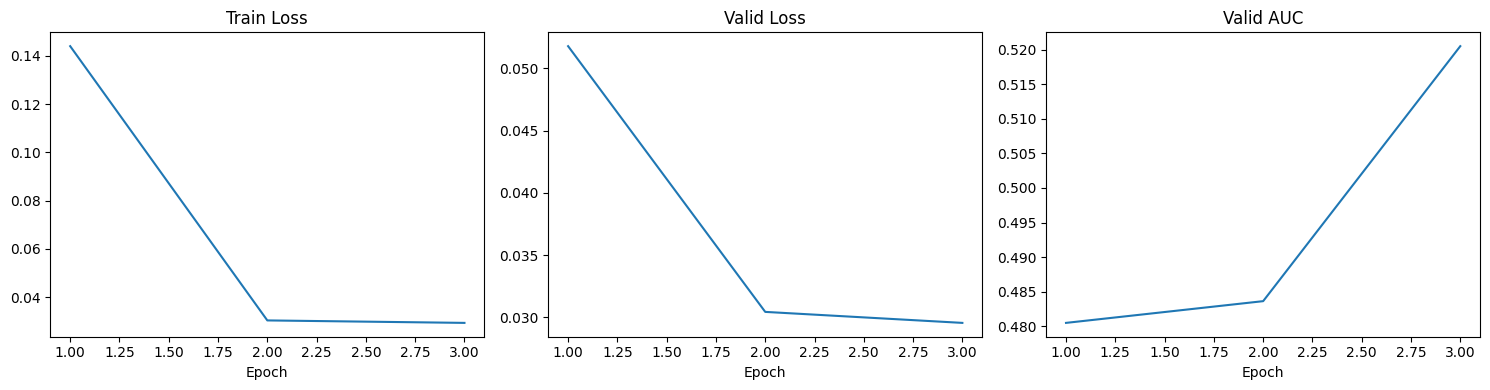

Weight saved to: /content/drive/Othercomputers/maeke/work/kaggle/birdclef-2026/experiment/exp001/output/weights/best_fold0.pth


In [ ]:
# ── 学習曲線の確認 ────────────────────────────────────────────
import matplotlib.pyplot as plt

log_df = pd.DataFrame(log_rows)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['tr_loss', 'va_loss', 'va_auc'], ['Train Loss', 'Valid Loss', 'Valid AUC']):
    ax.plot(log_df['epoch'], log_df[col])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/train_curve_fold{FOLD}.png', dpi=100)
plt.show()
print(f'Weight saved to: {WEIGHT_PATH}')

In [36]:
# ── Kaggle Dataset へ自動アップロード ────────────────────────
import json, os, subprocess
from getpass import getpass

KAGGLE_USERNAME = 'maekeso'
DATASET_SLUG    = 'birdclef2026-exp001-weights'
DATASET_TITLE   = 'BirdCLEF2026 exp001 Weights'

# ── 認証（~/.kaggle/kaggle.json に書き込む）──────────────────
kaggle_dir = os.path.expanduser('~/.kaggle')
kaggle_cfg = f'{kaggle_dir}/kaggle.json'
os.makedirs(kaggle_dir, exist_ok=True)

api_key = getpass('Kaggle API Key: ')
with open(kaggle_cfg, 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': api_key}, f)
os.chmod(kaggle_cfg, 0o600)
print('認証設定完了')

# ── dataset-metadata.json を作成 ──────────────────────────────
with open(f'{WEIGHT_DIR}/dataset-metadata.json', 'w') as f:
    json.dump({
        'title': DATASET_TITLE,
        'id': f'{KAGGLE_USERNAME}/{DATASET_SLUG}',
        'licenses': [{'name': 'CC0-1.0'}],
    }, f, indent=2)

# ── アップロード（初回: create / 2回目以降: version）────────────
print(f'Uploading to kaggle.com/{KAGGLE_USERNAME}/{DATASET_SLUG} ...')

result = subprocess.run(
    ['kaggle', 'datasets', 'create', '-p', WEIGHT_DIR, '--dir-mode', 'skip'],
    capture_output=True, text=True
)

if 'already exists' in result.stdout + result.stderr or result.returncode != 0:
    result = subprocess.run(
        ['kaggle', 'datasets', 'version', '-p', WEIGHT_DIR,
         '-m', f'epoch{best_epoch}_auc{best_auc:.4f}', '--dir-mode', 'skip'],
        capture_output=True, text=True
    )

print(result.stdout)
if result.returncode == 0:
    print(f'✓ Upload complete: https://www.kaggle.com/datasets/{KAGGLE_USERNAME}/{DATASET_SLUG}')
else:
    print(f'Error: {result.stderr}')

Kaggle API Key: ··········
認証設定完了
Uploading to kaggle.com/maekeso/birdclef2026-exp001-weights ...
Starting upload for file best_fold0.pth
401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/blobs.BlobApiService/StartBlobUpload

Error: 


In [38]:
 # Colabで手動確認
import json, os
with open(os.path.expanduser('~/.kaggle/kaggle.json')) as f:
    print(json.load(f))  # username と key が正しく入っているか確認

{'username': 'maekeso', 'key': 'KGAT_abd4a73b16ef729316787e8980e780a0'}
